# Расширенный разведочный анализ данных

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

## Подключение к аналитической базе данных 'oncology'

Доступ к переменным окружения:
- все конфиденциальные данные расположены в файле `/home/andrew/oncology_fhir_analytics/infrastructure/.env` и не сохранены в git-репозитории

In [2]:
# Определяем путь к .env файлу относительно текущего ноутбука
env_path = Path.cwd().parent / 'infrastructure' / '.env'
# Загружаем переменные из указанного пути
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"Конфигурация загружена из: {env_path}")
else:
    print(f"Файл .env не найден по пути: {env_path}")

Конфигурация загружена из: /home/andrew/oncology_fhir_analytics/infrastructure/.env


Подключение к аналитической базе данных

In [5]:
# Подключаемся к ClickHouse
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username=os.getenv('CLICKHOUSE_USER', 'default'),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
    database=os.getenv('CLICKHOUSE_DB', 'default')
)

def query_df(sql):
    return client.query_df(sql)

print("Подключение установлено.")

Подключение установлено.


## Демографический анализ

Помсотрим на структуру срегенированных пациентов по возрасту, полу, принадлежности к определенной рассе, семейному пложению и признаку еще жив пациент или уже нет

Создадим на основе ClickHouse таблицы `patients` датафрейма `df_patients`

In [6]:
# создание датафрейма
df_patients = query_df("""
SELECT 
    gender, 
    race, 
    marital_status,
    dateDiff('year', birth_date, today()) as age,                  
    is_deceased
FROM oncology.patients
""")

In [7]:
print(df_patients.shape)
print(df_patients.head())

(10673, 5)
   gender   race marital_status  age  is_deceased
0    male  White        Married   90            0
1  female  White        Married   89            1
2  female  White        Married   56            0
3  female  White        Widowed   84            1
4  female  White        Married   88            1


In [31]:
print("Основные статистики возраста:")
df_patients['age'].describe()

Основные статистики возраста:


count      10673.0
mean     76.106343
std      12.040693
min           45.0
25%           68.0
50%           80.0
75%           86.0
max           90.0
Name: age, dtype: Float64

In [9]:
print("Распределение по полу:")
gender_counts = df_patients['gender'].value_counts().reset_index()
total = gender_counts['count'].sum()
gender_counts['percentage'] = (gender_counts['count'] / total * 100).round(2)
gender_counts

Распределение по полу:


,gender,count,percentage
0,female,5457,51.13
1,male,5216,48.87


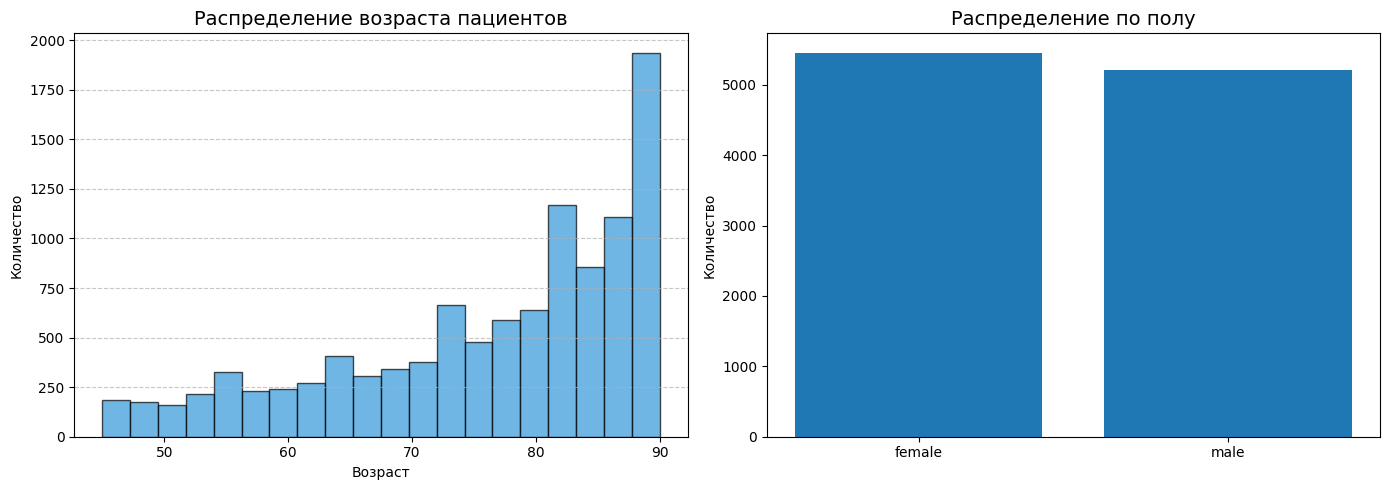

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма возраста
ax1.hist(df_patients['age'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax1.set_title('Распределение возраста пациентов', fontsize=14)
ax1.set_xlabel('Возраст')
ax1.set_ylabel('Количество')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
# Столбчатая диаграмма пола
gender_counts = df_patients['gender'].value_counts()
ax2.bar(gender_counts.index, gender_counts.values)
ax2.set_title('Распределение по полу', fontsize=14)
ax2.set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [12]:
print("Расределение по выживаемости:")
status_counts = df_patients['is_deceased'].value_counts().reset_index()
total = status_counts['count'].sum()
status_counts['percentage'] = (status_counts['count'] / total * 100).round(2)
status_counts

Расределение по выживаемости:


,is_deceased,count,percentage
0,0,6046,56.65
1,1,4627,43.35


In [14]:
print("Доля в группе пациентов представителей разных расс:")
race_counts = df_patients['race'].value_counts().reset_index()
total = race_counts['count'].sum()
race_counts['percentage'] = (race_counts['count'] / total * 100).round(2)
race_counts

Доля в группе пациентов представителей разных расс:


,race,count,percentage
0,White,8824,82.68
1,Black or African American,883,8.27
2,Asian,683,6.4
3,Other,137,1.28
4,Native Hawaiian or Other Pacific Islander,100,0.94
5,American Indian or Alaska Native,46,0.43


In [13]:
# Статиситка смертности по полу
gender_death_ct = pd.crosstab(df_patients['gender'], df_patients['is_deceased'])
gender_death_ct.columns = ['Alive', 'Deceased']
gender_death_ct['Mortality Rate (%)'] = (gender_death_ct['Deceased'] / 
                                         (gender_death_ct['Alive'] + gender_death_ct['Deceased']) * 100).round(2)

print("Статистика смертности по полу:")
gender_death_ct

Статистика смертности по полу:


,Alive,Deceased,Mortality Rate (%)
gender,,,
female,3122,2335,42.79
male,2924,2292,43.94


In [57]:
print("Распределение по семейному положению:")
marital_status_counts = df_patients['marital_status'].value_counts().reset_index()
total = marital_status_counts['count'].sum()
marital_status_counts['percentage'] = (marital_status_counts['count'] / total * 100).round(2)
marital_status_counts

Распределение по семейному положению:


,marital_status,count,percentage
0,Married,5844,54.75
1,Never Married,2181,20.43
2,Divorced,1922,18.01
3,Widowed,726,6.8


In [96]:
# Статиситка смертности по семейному положению
marital_status_death_ct = pd.crosstab(df_patients['marital_status'], df_patients['is_deceased'])
marital_status_death_ct.columns = ['Alive', 'Deceased']
marital_status_death_ct['Mortality Rate (%)'] = (marital_status_death_ct['Deceased'] / 
                                         (marital_status_death_ct['Alive'] + marital_status_death_ct['Deceased']) * 100).round(2)

print("Статистика смертности по семейному положению:")
marital_status_death_ct

Статистика смертности по семейному положению:


,Alive,Deceased,Mortality Rate (%)
marital_status,,,
Divorced,1109,813,42.30
Married,3313,2531,43.31
Never Married,1226,955,43.79
Widowed,398,328,45.18


### Выводы:

На основе полученных данных о 10673 пациентов можно сформулировать следующие детальные выводы:

1. Средний возраст (**76 лет**) и медиана (**80 лет**) указывают на то, что перед нами популяция пожилых людей. Это типично для онкологических данных. Известно, что риск заболеваемости раком растет с возрастом, поэтому при генерации синтетических данных скрпит был настроен на возрастную группу 50-90 лет.
1. Смещение распределения (Левосторонняя асимметрия). Медиана (80 лет) значительно выше среднего значения (76 лет). Это означает, что большая часть пациентов сосредоточена в диапазоне от 75 до 90 лет. 
Максимальный возраст ровно **90 лет**.
1. Межквартильный размах (IQR) составляет **68 – 86 лет**. 50% всех пациентов находятся в этом узком возрастном окне. Это основная целевая аудитория для построения аналитических моделей.
1. Гендерный баланс (Gender Distribution). В данных нет выраженного гендерного перекоса. Это позволяет проводить сравнительный анализ эффективности лечения и течения болезни для обоих полов без необходимости дополнительного взвешивания выборок.
1. Высокий уровень летальности (Survival Distribution). Это подтверждает реальность выборки (онкология + пожилой возраст). Данный датасет подходит для построения моделей предсказания выживаемости (Survival Analysis), так как накоплено достаточное количество целевых событий (смертей) для обучения алгоритмов.
1. Подавляющее большинство пациентов (**82.7%**) относятся к европеоидной расе (White). Данные могут быть смещены (biased) в сторону физиологических реакций, характерных для одной этнической группы. При обучении моделей машинного обучения нужно быть осторожным.
1. Отсутствие явной корреляции между полом и смертностью. Фактор пола, вероятно, сам по себе не является решающим для прогноза выживаемости.
1. Социально-демографический профиль (Marital Status). Более половины пациентов состоят в браке. Доля вдов/вдовцов (Widowed) составляет всего **6.8%**, что неожиданно мало для населения с медианным возрастом 80 лет.
1. Влияние семейного положения на смертность. Самый высокий уровень смертности наблюдается среди вдовцов/вдов. Требует проверки гипотеза о том, что потеря супруга может негативно сказываться на прогнозе выживаемости у пожилых пациентов.

## Анализ клинических групп

### Изучение структуры диагнозов

In [21]:
df_conditions = query_df("""
SELECT 
    patient_id,
    code, 
    display,
    clinical_status,
    verification_status                                             
FROM oncology.conditions
""")
df_conditions.head()

,patient_id,code,display,clinical_status,verification_status
0,b9b9d211-f520-aea1-0098-86b3fb2e73c2,68496003,Polyp of colon (disorder),resolved,confirmed
1,4734766a-ddfc-f672-00c7-9506bb7a7bd7,68496003,Polyp of colon (disorder),resolved,confirmed
2,4734766a-ddfc-f672-00c7-9506bb7a7bd7,68496003,Polyp of colon (disorder),resolved,confirmed
3,c5883ec8-43f9-36de-00e9-2242b44d23c9,68496003,Polyp of colon (disorder),resolved,confirmed
4,10a81c04-78ef-1c0a-0117-b2f85d6cdaa1,68496003,Polyp of colon (disorder),active,confirmed


In [22]:
print("Распределение диагнозов:")
condition_counts = df_conditions[['code','display']].value_counts().reset_index()
total = condition_counts['count'].sum()
condition_counts['percentage'] = (condition_counts['count'] / total * 100).round(2)
condition_counts

Распределение диагнозов:


,code,display,count,percentage
0,68496003,Polyp of colon (disorder),8024,37.26
1,713197008,Recurrent rectal polyp (disorder),3927,18.23
2,271737000,Anemia (disorder),3195,14.83
3,109838007,Overlapping malignant neoplasm of colon (disor...,2404,11.16
4,363406005,Malignant neoplasm of colon (disorder),2136,9.92
5,93761005,Primary malignant neoplasm of colon (disorder),1133,5.26
6,236077008,Protracted diarrhea (finding),344,1.60
7,6072007,Bleeding from anus (disorder),344,1.60
8,94260004,Metastatic malignant neoplasm to colon (disorder),30,0.14


In [37]:
print("Распределение онкологических диагнозов")
target_codes = ['68496003', '713197008', '93761005', '109838007', '363406005', '94260004']

df_cond_stats = (
    df_conditions[df_conditions['code'].isin(target_codes)]
    .groupby(['code', 'display'])
    .agg(
        count=('patient_id', 'count'),
        unique_patients=('patient_id', 'nunique')
    )
    .reset_index()
    .sort_values(by='count', ascending=False)
)

# 3. Вывод результата
df_cond_stats

Распределение онкологических диагнозов


,code,display,count,unique_patients
2,68496003,Polyp of colon (disorder),8024,6452
3,713197008,Recurrent rectal polyp (disorder),3927,3842
0,109838007,Overlapping malignant neoplasm of colon (disor...,2404,2404
1,363406005,Malignant neoplasm of colon (disorder),2136,2136
4,93761005,Primary malignant neoplasm of colon (disorder),1133,1133
5,94260004,Metastatic malignant neoplasm to colon (disorder),30,30


In [ ]:
total_patients = df_patients.shape[0]

# Маппинг целевых групп
def map_condition_group(code):
    if code in ['68496003', '713197008']:
        return 'Pre-cancerous (Polyps)'
    elif code in ['109838007', '363406005', '93761005']:
        return 'Primary Cancer'
    elif code == '94260004':
        return 'Metastatic to colon'
    else:
        return 'Other'

# Создаем колонку с целевыми группами
df_targets = df_conditions[df_conditions['code'].isin(['68496003', '713197008', '93761005', '109838007', '363406005', '94260004'])].copy()
df_targets['condition_group'] = df_targets['code'].apply(map_condition_group)

# Группируем по новой колонке и считаем уникальных пациентов
df_summary = (
    df_targets.groupby('condition_group')
    .agg(unique_patients=('patient_id', 'nunique'))
    .reset_index()
)

# Считаем процент охвата популяции
df_summary['population_coverage'] = (
    (df_summary['unique_patients'] / total_patients) * 100
).round(2)

# Сортируем результат
order = ['Pre-cancerous (Polyps)', 'Primary Cancer', 'Metastatic to colon']
df_summary['condition_group'] = pd.Categorical(df_summary['condition_group'], categories=order, ordered=True)
df_summary = df_summary.sort_values('condition_group').reset_index(drop=True)

print("Распределение целевых групп среди пациентов:")
df_summary

Распределение целевых групп среди пациентов:


,condition_group,unique_patients,population_coverage
0,Pre-cancerous (Polyps),6452,60.45
1,Primary Cancer,5673,53.15
2,Metastatic to colon,30,0.28


In [42]:
# 1. Определяем списки кодов для каждой категории
polyps_codes = ['68496003', '713197008']
cancer_codes = ['109838007', '363406005', '93761005']

# 2. Создаем временную таблицу, где для каждого пациента отметим наличие полипов и рака
# Мы группируем по patient_id и проверяем наличие хотя бы одного кода из списков
patient_flags = df_conditions.groupby('patient_id').agg(
    has_polyp=('code', lambda x: int(any(c in polyps_codes for c in x))),
    has_cancer=('code', lambda x: int(any(c in cancer_codes for c in x)))
).reset_index()

# 3. Теперь группируем по флагам и считаем количество пациентов в каждой комбинации
df_intersection = (
    patient_flags.groupby(['has_polyp', 'has_cancer'])
    .size()
    .reset_index(name='patient_count')
)

# 4. Сортируем порядок строк: (0,0), (1,0), (0,1), (1,1)
df_intersection = df_intersection.sort_values(by=['has_cancer', 'has_polyp']).reset_index(drop=True)

print("Проверка: Сколько пациентов имеют и полип, и рак (временная последовательность)")
df_intersection

Проверка: Сколько пациентов имеют и полип, и рак (временная последовательность)


,has_polyp,has_cancer,patient_count
0,0,0,30
1,1,0,1093
2,0,1,314
3,1,1,5359


### Выводы:

По результатам разведочного анализа диагнозов можно сделать сделующие выводы:

1. Подтверждение классического пути канцерогенеза. **94,5%** пациентов с раком толстой кишки (5359 из 5673) имеют в анамнезе зафиксированные полипы. Это делает признак наличие одним из самых сильных предикторов в будущей модели.
1. В топ-диагнозов попали классические «маски» и симптомы колоректального рака: анемия и кишечное кровотечение. Эти специфические симптомы могут иметь высокий «вес» в модели классификации стадий.
1. Для кодов злокачественных новообразований количество записей совпадает с количеством уникальных пациентов. Это говорит об отсутствии дублирования ресурсов Condition для одного и того же случая болезни.
1. Почти **60%** пациентов с полипами (3842 из 6452) имеют диагноз «Рецидивирующий полип». 
Он может являться признаком неблагоприятного течения предракового процесса.

### Объединение данных таблиц patients и conditions

#### Формирование датафрейма

При формировании датайфрейма мы добавили следующие признаки:
1. Разделим пациентов на три клинические группы:
    - Control: Нет ни полипов, ни рака.
    - Polyps: Есть полипы, но (пока) нет рака.
    - CRC: Есть подтвержденный диагноз рака.
1. Возраст на момент постановки даигноза, который является более информативным, чем возраст на текущий момент

In [71]:
df_clinic_groups = query_df(
    """
SELECT 
    p.patient_id,
    p.gender,
    p.birth_date,
    dateDiff('year', p.birth_date, today()) as current_age,
    p.is_deceased,
    p.race,
    p.marital_status,
    -- 1. Определяем клиническую группу
    multiIf(
        c.patient_id != toUUID('00000000-0000-0000-0000-000000000000'), 'CRC', 
        pol.patient_id != toUUID('00000000-0000-0000-0000-000000000000'), 'Polyps', 
        'Control'
    ) as clinical_group,
    -- 2. Логика даты установки диагноза (или дата рождения для Control)
    multiIf(
        c.patient_id != toUUID('00000000-0000-0000-0000-000000000000'), formatDateTime(c.crc_diag_at, '%Y-%m-%d'),
        pol.patient_id != toUUID('00000000-0000-0000-0000-000000000000'), formatDateTime(pol.first_polyp_at, '%Y-%m-%d'),
        toString(p.birth_date) -- Для контрольной группы берем дату рождения как строку
    ) as diagnosis_date,
    -- 3. Возраст постановки диагноза (0 для Control, так как diag_date == birth_date)
    multiIf(
        c.patient_id != toUUID('00000000-0000-0000-0000-000000000000'), dateDiff('year', p.birth_date, toDate(c.crc_diag_at)),
        pol.patient_id != toUUID('00000000-0000-0000-0000-000000000000'), dateDiff('year', p.birth_date, toDate(pol.first_polyp_at)),
        0 -- Возраст 0 для контрольной группы
    ) as age_at_diagnosis
FROM oncology.patients p
LEFT JOIN (
    SELECT patient_id, min(onset_at) as first_polyp_at
    FROM oncology.conditions 
    WHERE code IN ('68496003', '713197008') 
    GROUP BY patient_id
) AS pol ON p.patient_id = pol.patient_id
LEFT JOIN (
    SELECT patient_id, min(onset_at) as crc_diag_at
    FROM oncology.conditions 
    WHERE code IN ('109838007', '363406005', '93761005', '94260004') 
    GROUP BY patient_id
) AS c ON p.patient_id = c.patient_id
"""
)

# Проверяем результат
df_clinic_groups.head()

,p.patient_id,gender,birth_date,current_age,is_deceased,race,marital_status,clinical_group,diagnosis_date,age_at_diagnosis
0,79b3eb75-48d2-12db-0000-45ede7a4ca93,male,1936-06-19,90,0,White,Married,Control,1936-06-19,0
1,87fc29f3-c7c9-83e8-0002-d57959c8099f,female,1937-01-31,89,1,White,Married,CRC,2008-02-28,71
2,d0012d8f-6c2a-9072-0003-4f7ac4c1a0a0,female,1970-01-02,56,0,White,Married,CRC,2026-03-10,56
3,aab9d7e8-5733-a839-0011-2b0c1a77dfa5,female,1942-10-04,84,1,White,Widowed,Control,1942-10-04,0
4,79eb6a31-1fbf-71fc-0011-34251ec955c0,female,1938-05-18,88,1,White,Married,CRC,2014-10-31,76


In [72]:
print("Распределение пациентов по группам")
print(df_clinic_groups['clinical_group'].value_counts().reset_index())

Распределение пациентов по группам
  clinical_group  count
0            CRC   5703
1        Control   3877
2         Polyps   1093


#### Сравнение клинических групп по возрасту на текущий момент

In [73]:
# Статистика возраста на текущий момент по группам
age_stats = df_clinic_groups.groupby('clinical_group')['current_age'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
print("Статистика возраста на текущий момент по группам:")
print(age_stats)

Статистика возраста на текущий момент по группам:
                count       mean        std  min  median  max
clinical_group                                               
CRC              5703  79.487989   9.150759   46    82.0   90
Control          3877  70.260511  14.042017   45    72.0   90
Polyps           1093  79.197621    9.44074   51    82.0   90


/tmp/ipykernel_10945/3966914019.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=groups, patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})


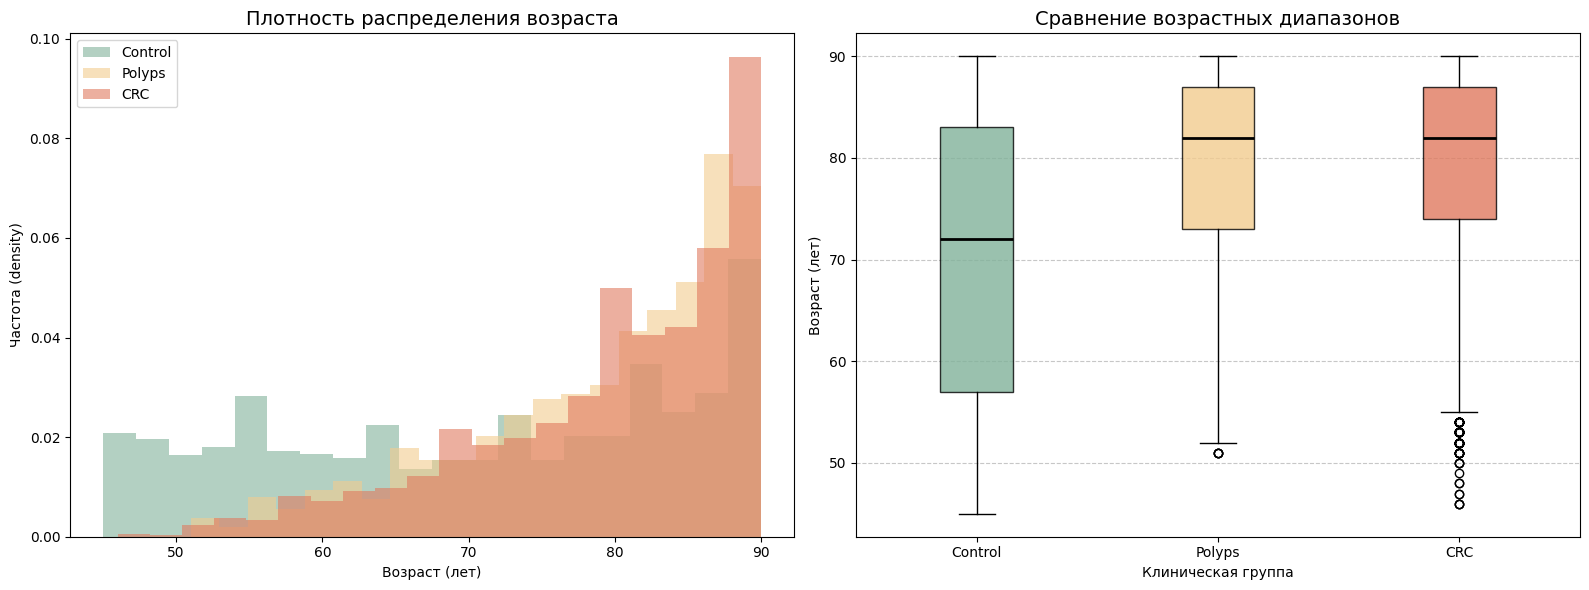

In [74]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
groups = ['Control', 'Polyps', 'CRC']
colors = ['#81b29a', '#f2cc8f', '#e07a5f']

# Гистограммы (Плотность распределения)
for group, color in zip(groups, colors):
    subset = df_clinic_groups[df_clinic_groups['clinical_group'] == group]
    ax1.hist(subset['current_age'], bins=20, alpha=0.6, label=group, color=color, density=True)

ax1.set_title('Плотность распределения возраста', fontsize=14)
ax1.set_xlabel('Возраст (лет)')
ax1.set_ylabel('Частота (density)')
ax1.legend()

# Boxplot (Сравнение медиан)
data_to_plot = [df_clinic_groups[df_clinic_groups['clinical_group'] == g]['current_age'] for g in groups]

bp = ax2.boxplot(data_to_plot, labels=groups, patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax2.set_title('Сравнение возрастных диапазонов', fontsize=14)
ax2.set_xlabel('Клиническая группа')
ax2.set_ylabel('Возраст (лет)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [75]:
# Статистика: возраст постановки диагноза (CRC/Polyps) vs текущий возраст (Control)
# Для Control берем current_age, для остальных - age_at_diagnosis
df_clinic_groups['age_for_analysis'] = df_clinic_groups.apply(
    lambda x: x['current_age'] if x['clinical_group'] == 'Control' else x['age_at_diagnosis'], 
    axis=1
)

# Формируем итоговую таблицу
analysis_stats = df_clinic_groups.groupby('clinical_group')['age_for_analysis'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(2)

print("Статистика: возраст постановки диагноза (CRC/Polyps) vs текущий возраст (Control):")
print(analysis_stats)

Статистика: возраст постановки диагноза (CRC/Polyps) vs текущий возраст (Control):
                count   mean    std  min  median  max
clinical_group                                       
CRC              5703  62.35   9.07   35    62.0   82
Control          3877  70.26  14.04   45    72.0   90
Polyps           1093  60.67   8.00   50    60.0   76


#### Сравнение клинических групп по возрасту постановки диагноза

/tmp/ipykernel_10945/2918832265.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=groups, patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})


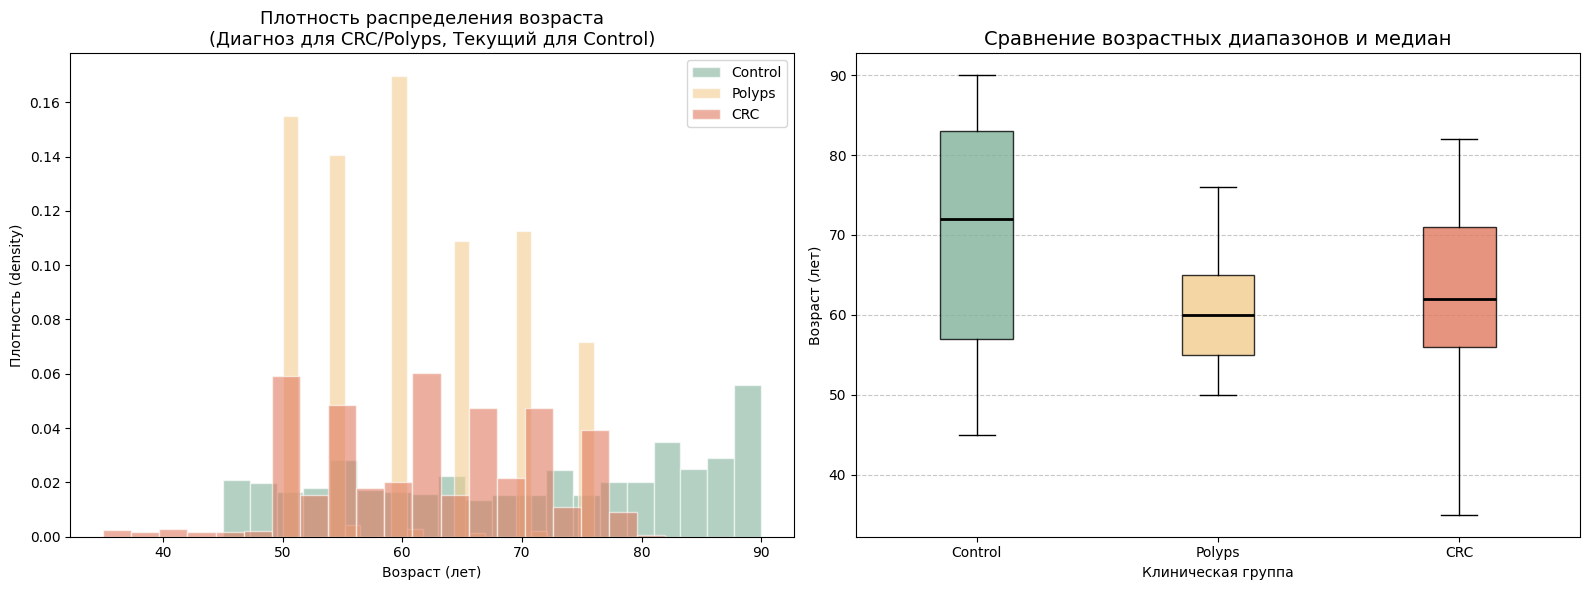

In [77]:
# Для Control берем текущий возраст, для остальных — возраст манифестации
data_control = df_clinic_groups[df_clinic_groups['clinical_group'] == 'Control']['current_age']
data_polyps = df_clinic_groups[df_clinic_groups['clinical_group'] == 'Polyps']['age_at_diagnosis']
data_crc = df_clinic_groups[df_clinic_groups['clinical_group'] == 'CRC']['age_at_diagnosis']

data_to_plot = [data_control, data_polyps, data_crc]
groups = ['Control', 'Polyps', 'CRC']
colors = ['#81b29a', '#f2cc8f', '#e07a5f']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Гистограммы (Плотность распределения)
for label, data_subset, color in zip(groups, data_to_plot, colors):
    ax1.hist(data_subset, bins=20, alpha=0.6, label=label, color=color, density=True, edgecolor='white')

ax1.set_title('Плотность распределения возраста\n(Диагноз для CRC/Polyps, Текущий для Control)', fontsize=13)
ax1.set_xlabel('Возраст (лет)')
ax1.set_ylabel('Плотность (density)')
ax1.legend()

# Boxplot (Сравнение медиан)
bp = ax2.boxplot(data_to_plot, labels=groups, patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax2.set_title('Сравнение возрастных диапазонов и медиан', fontsize=14)
ax2.set_xlabel('Клиническая группа')
ax2.set_ylabel('Возраст (лет)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Распределение пациентов в клинических группах по полу

In [78]:
# Группируем по клинической группе и полу
gender_dist = df_clinic_groups.groupby(['clinical_group', 'gender']).size().unstack(fill_value=0)

# Добавляем итоговые значения и проценты
gender_dist['Total'] = gender_dist.sum(axis=1)
gender_dist['Female %'] = (gender_dist['female'] / gender_dist['Total'] * 100).round(2)
gender_dist['Male %'] = (gender_dist['male'] / gender_dist['Total'] * 100).round(2)

print("Статистика распределения пациентов по полу:")
print(gender_dist[['female', 'male', 'Total', 'Female %', 'Male %']])

Статистика распределения пациентов по полу:
gender          female  male  Total  Female %  Male %
clinical_group                                       
CRC               2915  2788   5703     51.11   48.89
Control           1967  1910   3877     50.74   49.26
Polyps             575   518   1093     52.61   47.39


#### Распределение умерших в клинических группах

In [79]:
# Рассчитываем количество живых и умерших
mortality_summary = df_clinic_groups.groupby('clinical_group')['is_deceased'].agg(['count', 'sum'])
mortality_summary.columns = ['Total', 'Deaths']

# Добавляем расчет выживших и летальность
mortality_summary['Alive'] = mortality_summary['Total'] - mortality_summary['Deaths']
mortality_summary['Mortality_Rate_%'] = (mortality_summary['Deaths'] / mortality_summary['Total'] * 100).round(2)

print("Статистика умерших по клиническим группам:")
print(mortality_summary[['Alive', 'Deaths', 'Total', 'Mortality_Rate_%']])

Статистика умерших по клиническим группам:
                 Alive  Deaths  Total  Mortality_Rate_%
clinical_group                                         
CRC             2819.0    2884   5703             50.57
Control         2571.0    1306   3877             33.69
Polyps           656.0     437   1093             39.98


#### Сводные отчеты по смертности в клинических группах

In [82]:
# Создаем расчетный возраст: для больных - возраст диагноза, для контроля - текущий
df_clinic_groups['age_for_analysis'] = df_clinic_groups.apply(
    lambda x: x['current_age'] if x['clinical_group'] == 'Control' else x['age_at_diagnosis'], 
    axis=1
)

# Определяем границы и метки групп
bins = [0, 50, 65, 80, 120]
labels = ['<50 лет', '50-64 года', '65-79 лет', '80+ лет']

# Создаем колонку категорий
df_clinic_groups['age_category'] = pd.cut(
    df_clinic_groups['age_for_analysis'], 
    bins=bins, 
    labels=labels, 
    right=False
)

# Функция для единообразия стилизации отчетов
def style_mortality_report(df, title):
    return df.style \
        .bar(subset=['Летальность (%)'], color='#e07a5f', vmin=0, vmax=100) \
        .format({
            'Всего пациентов': '{:,.0f}', 
            'Кол-во смертей': '{:,.0f}', 
            'Летальность (%)': '{:.1f}%'
        }) \
        .set_caption(title) \
        .set_table_styles([
            {'selector': 'th', 'props': [('color', '#3d405b'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding', '10px'), ('color', '#3d405b')]}
        ])

# Количество умерших в зависимости от пола

gender_mortality = df_clinic_groups.groupby(['clinical_group', 'gender']).agg(
    total_patients=('is_deceased', 'count'),
    deaths=('is_deceased', 'sum'),
    mortality_rate=('is_deceased', lambda x: x.mean() * 100)
)
gender_mortality.columns = ['Всего пациентов', 'Кол-во смертей', 'Летальность (%)']

styled_gender_report = style_mortality_report(
    gender_mortality, 
    "Анализ летальности: Количество умерших в зависимости от пола"
)

# Количество умерших в разных возрастных группах

age_mortality = df_clinic_groups.groupby(['clinical_group', 'age_category'], observed=True).agg(
    total_patients=('is_deceased', 'count'),
    deaths=('is_deceased', 'sum'),
    mortality_rate=('is_deceased', lambda x: x.mean() * 100)
)
age_mortality.columns = ['Всего пациентов', 'Кол-во смертей', 'Летальность (%)']

styled_age_report = style_mortality_report(
    age_mortality, 
    "Анализ летальности: Количество умерших в зависимости от возрастных групп"
)

display(styled_gender_report)
display(styled_age_report)

### Выводы:

На основе проведенного разведочного анализа клинических групп можно сделать следующие выводы:

1. Средний возраст постановки диагноза «Полип» (**60.7 лет**) на 1.7 года меньше возраста постановки диагноза «Рак» (**62.4 года**). Это подтверждает наличие в данных временного окна для профилактического вмешательства.

1. Медианный возраст контрольной группы (**72 года**) значительно выше возраста манифестации рака. Это ценно для модели: у нас есть примеры пожилых людей, доживших до преклонного возраста без развития целевой патологии.

1. В группе CRC самая высокая летальность наблюдается в категории **до 50 лет (61.2%)**. Это соответствует клинической реальности: колоректальный рак в молодом возрасте часто протекает более агрессивно и выявляется на поздних стадиях.

1. Группа Polyps демонстрирует промежуточную летальность (**~40%**), что выше контроля (**~33%**). Это подтверждает, что наличие полипов само по себе является маркером снижения общего прогноза выживаемости по сравнению со здоровой популяцией.

1. В контрольной группе резкий скачок летальности происходит только после **80 лет (66.6%)**, что является ожидаемым биологическим трендом и подтверждает адекватность синтетической генерации данных.

1. Группы сбалансированы по полу (отклонение не более 2.6%). Фактор пола, вероятно, не будет являться доминирующим предиктором, но его стоит сохранить в модели для учета кросс-факторных взаимодействий.

1. Мы имеем **2884** случая смерти в группе рака и **437** в группе полипов. Такого объема «целевых событий» (Label = 1) более чем достаточно для стабильного обучения классификаторов и моделей Survival Analysis.

## Анализ Observation